# Modeling the Airbnb listings

In [18]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import (train_test_split, cross_val_score,RandomizedSearchCV)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Load dataset
all_data = pd.read_csv("data/clean_data.csv")
all_data.head(n=5)

,id,name,host_id,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,city
0,2265,Zen-East in the Heart of Austin (monthly rental),2466,30.27752,-97.71377,Entire home/apt,179,7,26,0.36,3,35,Austin
1,5456,"Walk to 6th, Rainey St and Convention Ctr",8028,30.26057,-97.73441,Entire home/apt,108,2,575,24.16,1,324,Austin
2,6448,"Secluded Studio @ Zilker - King Bed, Bright & ...",14156,30.26034,-97.76487,Entire home/apt,146,3,254,2.06,1,201,Austin
3,8502,Woodland Studio Lodging,25298,30.23466,-97.73682,Entire home/apt,44,3,46,1.08,1,59,Austin
4,13035,Historic house in highly walkable East Austin,50793,30.26098,-97.73072,Entire home/apt,150,30,12,0.11,2,331,Austin


## Model Data Preparation

In [19]:
# Log-transformation
all_data = all_data.copy()
all_data["log_price"] = np.log1p(all_data["price"])

# Feature selection

## Numerical features
numeric_features = ["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count"]

## Categorical features
categorical_features = ["room_type", "city"]

## Target variable
X = all_data[numeric_features + categorical_features]
y = all_data["log_price"]

# Model data preparation
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))])
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])     


## Initial Model Training - Linear Regression vs. Random Forest (RF)

In [20]:
city_results = {}

for city, df_city in all_data.groupby("city"):

    X = df_city[numeric_features + categorical_features]
    y = np.log1p(df_city["price"])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    models = {"Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)}

    print(f"\n===== City: {city} =====")
    city_results[city] = {}

    for name, model in models.items():

        pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)

        # predictions in log space
        y_pred_log = pipe.predict(X_test)

        # convert back to real price
        y_test_real = np.expm1(y_test)
        y_pred_real = np.expm1(y_pred_log)

        r2 = r2_score(y_test, y_pred_log)
        mae_real = mean_absolute_error(y_test_real, y_pred_real)

        print(f"\n{name}")
        print("R² (log scale):", round(r2, 4))
        print("MAE (real price):", round(mae_real, 2))

        city_results[city][name] = {"model": pipe, "r2": r2, "mae_real": mae_real}

    # Feature importance (RF only)
    rf_pipe = city_results[city]["Random Forest"]["model"]

    ohe = rf_pipe.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    feature_names = numeric_features + list(cat_feature_names)

    importances = rf_pipe.named_steps["model"].feature_importances_
    feat_importance = (pd.Series(importances, index=feature_names).sort_values(ascending=False))

    print("\nTop RF Features:")
    print(feat_importance.head(10))



===== City: Austin =====

Linear Regression
R² (log scale): 0.3186
MAE (real price): 164.35

Random Forest
R² (log scale): 0.5157
MAE (real price): 142.07

Top RF Features:
latitude                          0.187660
longitude                         0.181512
reviews_per_month                 0.150476
room_type_Private room            0.137216
minimum_nights                    0.103128
number_of_reviews                 0.091875
calculated_host_listings_count    0.088379
room_type_Shared room             0.058873
room_type_Hotel room              0.000881
dtype: float64

===== City: Bangkok =====

Linear Regression
R² (log scale): 0.1071
MAE (real price): 571.4

Random Forest
R² (log scale): 0.3772
MAE (real price): 461.88

Top RF Features:
latitude                          0.279889
longitude                         0.275483
calculated_host_listings_count    0.133603
number_of_reviews                 0.073275
room_type_Shared room             0.070790
reviews_per_month                 0

## Main Discussion

- What are the most important features?

Latitude and longitude are two of the most important features in all cities, indicating that location and, possibly, distance to the city center determines the price for each listing, more so than the space features or the host reputation.

- Is the behaviour similar throughout the cities?

Latitude and longitude account for up 40-50% of the model variance in all cities. All other features have a variable importance, specific for each city. In most cities (all except Bangkok), room type is also relevant as the private room type is preferred. Other features such as minimum nights or features regarding the host reputation have limited influence on the price of the listings.


- Modelling choice: is Random Forest appropriate for the nature of our data?

Random Forest consistently achieves higher $R**2$ than Linear Regression because housing prices follow non-linear patterns and interaction effects that are captured by a tree-based model such as Random Forest.


=== Plots for Austin ===


C:\Users\carol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


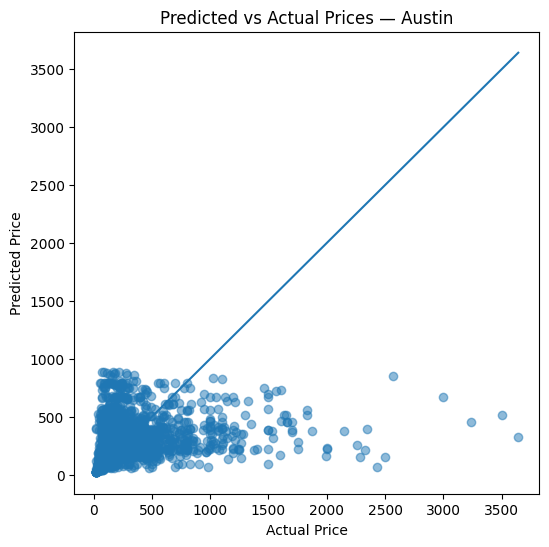

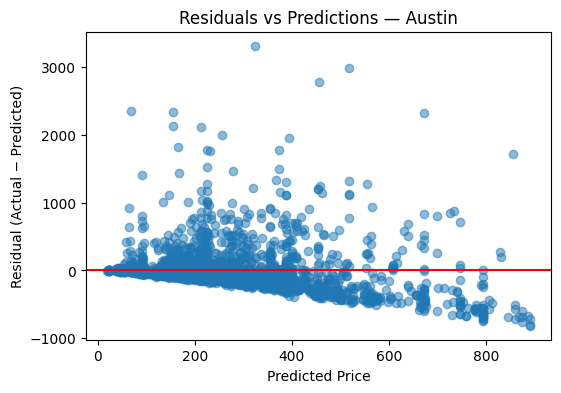

C:\Users\carol\AppData\Local\Temp\ipykernel_7828\2838755797.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = bins.groupby(bins).apply(lambda x: np.mean(np.abs(residuals[x.index])))


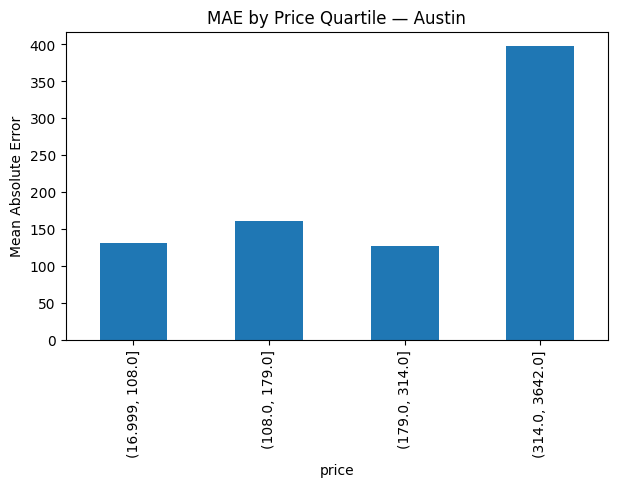


=== Plots for Bangkok ===


C:\Users\carol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


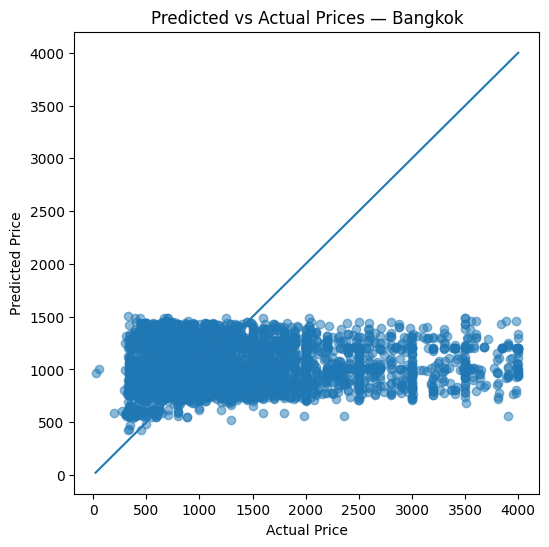

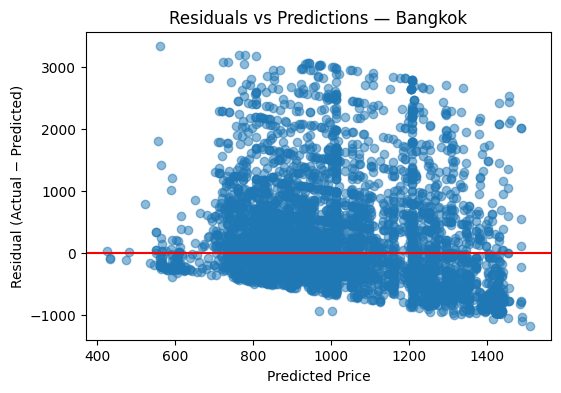

C:\Users\carol\AppData\Local\Temp\ipykernel_7828\2838755797.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = bins.groupby(bins).apply(lambda x: np.mean(np.abs(residuals[x.index])))


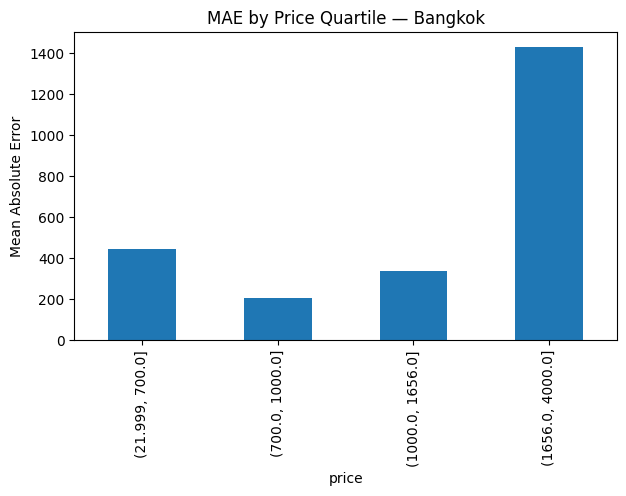


=== Plots for Buenos Aires ===


C:\Users\carol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


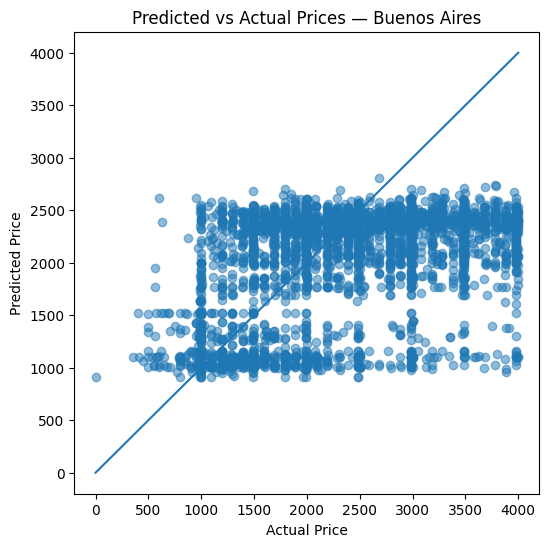

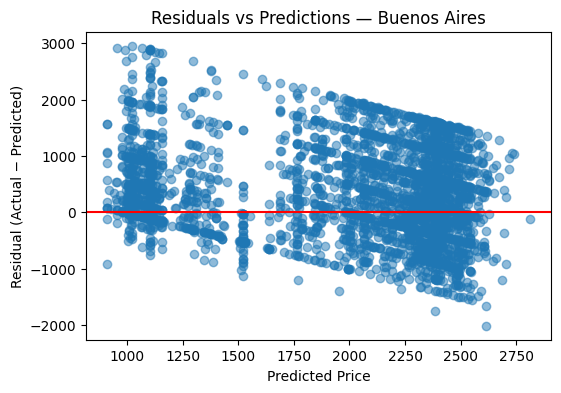

C:\Users\carol\AppData\Local\Temp\ipykernel_7828\2838755797.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = bins.groupby(bins).apply(lambda x: np.mean(np.abs(residuals[x.index])))


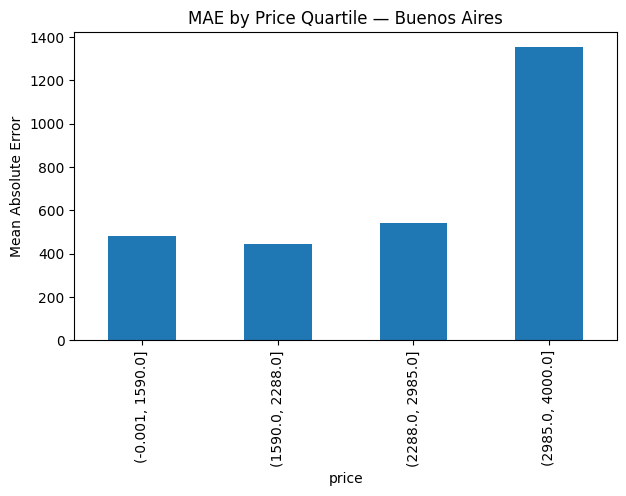


=== Plots for Cape Town ===


C:\Users\carol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


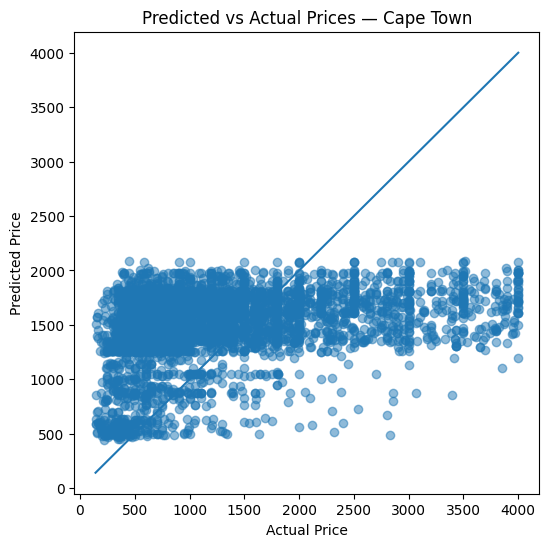

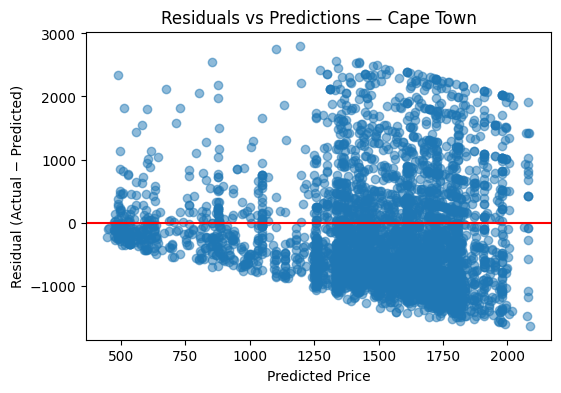

C:\Users\carol\AppData\Local\Temp\ipykernel_7828\2838755797.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = bins.groupby(bins).apply(lambda x: np.mean(np.abs(residuals[x.index])))


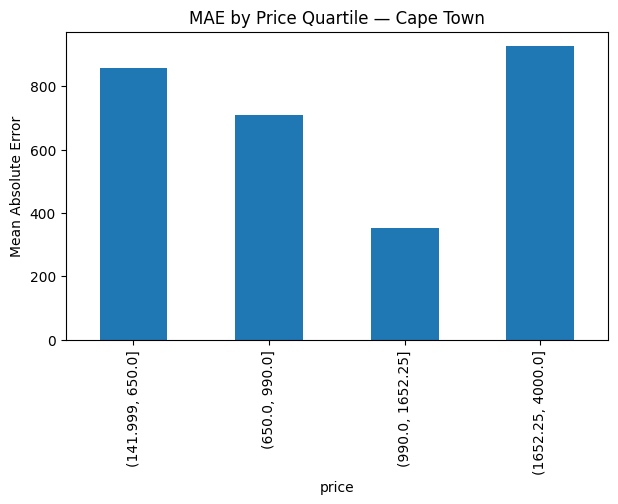

C:\Users\carol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== Plots for Istanbul ===


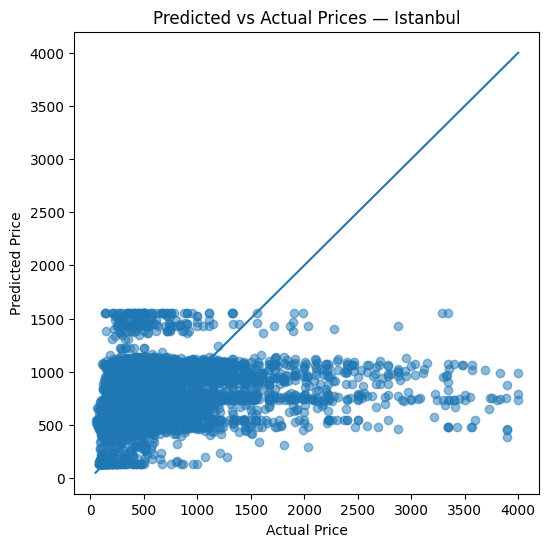

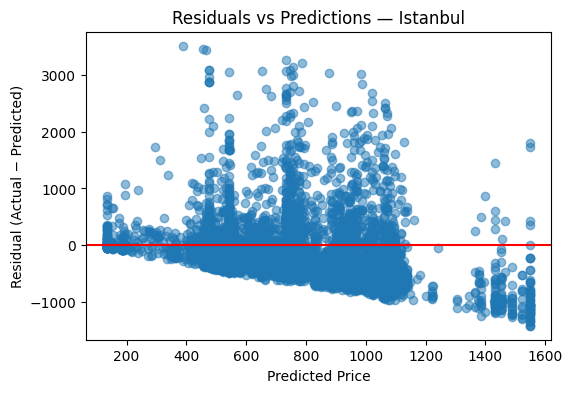

C:\Users\carol\AppData\Local\Temp\ipykernel_7828\2838755797.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = bins.groupby(bins).apply(lambda x: np.mean(np.abs(residuals[x.index])))


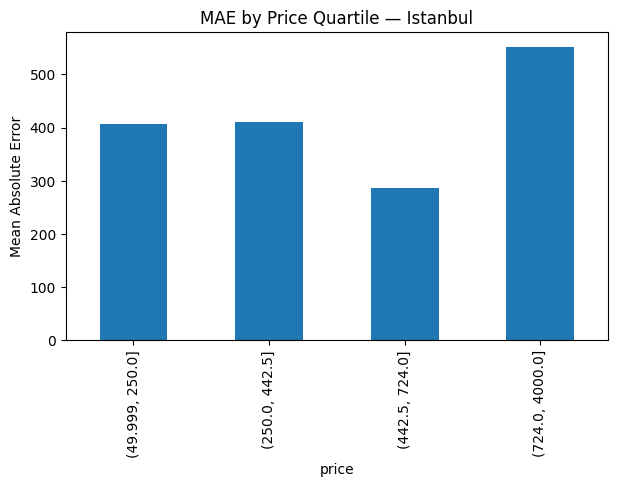


=== Plots for Melbourne ===


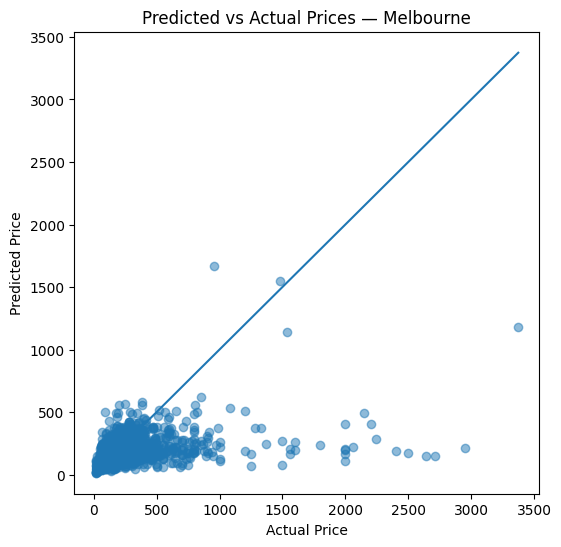

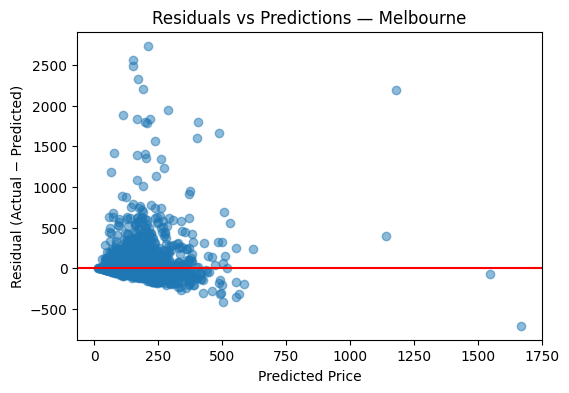

C:\Users\carol\AppData\Local\Temp\ipykernel_7828\2838755797.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = bins.groupby(bins).apply(lambda x: np.mean(np.abs(residuals[x.index])))


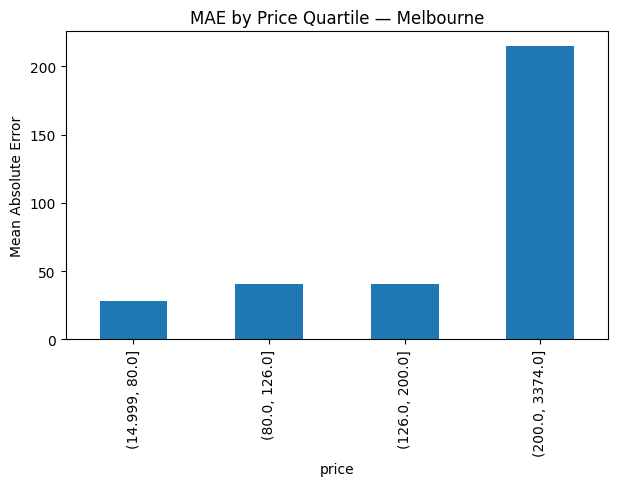

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

for city, models in city_results.items():
    print(f"\n=== Plots for {city} ===")
    rf_pipe = models["Random Forest"]["model"]

    df_city = all_data[all_data["city"] == city]
    X = df_city[numeric_features + categorical_features]
    y = np.log1p(df_city["price"])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    y_pred_log = rf_pipe.predict(X_test)
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    residuals = y_test_real - y_pred_real

    # Predicted vs Actual
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_real, y_pred_real, alpha=0.5)
    plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()])
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Predicted vs Actual Prices — {city}")
    plt.show()

    # Residuals vs Predicted
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred_real, residuals, alpha=0.5)
    plt.axhline(0, color="red")
    plt.xlabel("Predicted Price")
    plt.ylabel("Residual (Actual − Predicted)")
    plt.title(f"Residuals vs Predictions — {city}")
    plt.show()

    # MAE by Price Quartile
    bins = pd.qcut(y_test_real, q=4)
    mae_by_bin = bins.groupby(bins).apply(lambda x: np.mean(np.abs(residuals[x.index])))
    plt.figure(figsize=(7, 4))
    mae_by_bin.plot(kind="bar")
    plt.ylabel("Mean Absolute Error")
    plt.title(f"MAE by Price Quartile — {city}")
    plt.show()
